<a href="https://colab.research.google.com/github/Muqqadas30/fsdl-my-labs/blob/main/lab06/lab06_annotation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt
import random

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
train_raw = datasets.FashionMNIST(root="./data", train=True, download=True)

print("Dataset type:", type(train_raw))
print("Total samples:", len(train_raw))
print("Image type:", type(train_raw.data))
print("Image shape:", train_raw.data.shape)
print("Labels shape:", train_raw.targets.shape)

sample_image, sample_label = train_raw[0]
print("\nSample image type:", type(sample_image))
print("Sample label:", sample_label)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.9MB/s]

Dataset type: <class 'torchvision.datasets.mnist.FashionMNIST'>
Total samples: 60000
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([60000, 28, 28])
Labels shape: torch.Size([60000])

Sample image type: <class 'PIL.Image.Image'>
Sample label: 9


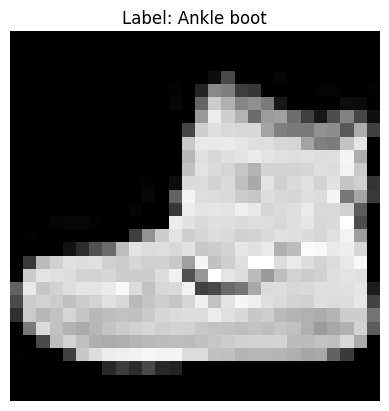

In [4]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.imshow(sample_image, cmap="gray")
plt.title(f"Label: {class_names[sample_label]}")
plt.axis("off")
plt.show()

In [5]:
from torchvision.transforms import ToTensor

class BaseDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


images_list = [train_raw[i][0] for i in range(10)]
labels_list = [train_raw[i][1] for i in range(10)]

dataset = BaseDataset(images_list, labels_list, transform=ToTensor())
im, label = dataset[0]
print("Transformed image shape:", im.shape)
print("Label:", class_names[label])

Transformed image shape: torch.Size([1, 28, 28])
Label: Ankle boot


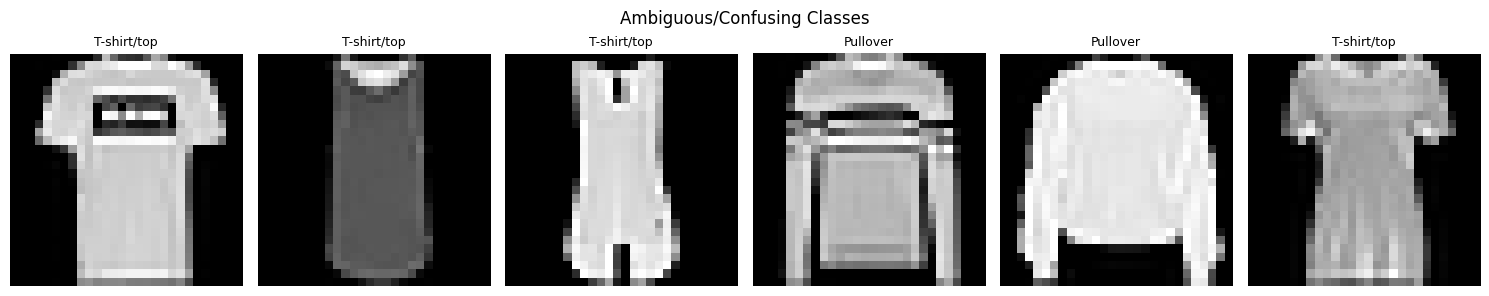

In [6]:
confusing_classes = [0, 2, 6]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
shown = 0
idx = 0
while shown < 6:
    img, label = train_raw[idx]
    if label in confusing_classes:
        axes[shown].imshow(img, cmap="gray")
        axes[shown].set_title(class_names[label], fontsize=9)
        axes[shown].axis("off")
        shown += 1
    idx += 1

plt.suptitle("Ambiguous/Confusing Classes")
plt.tight_layout()
plt.show()

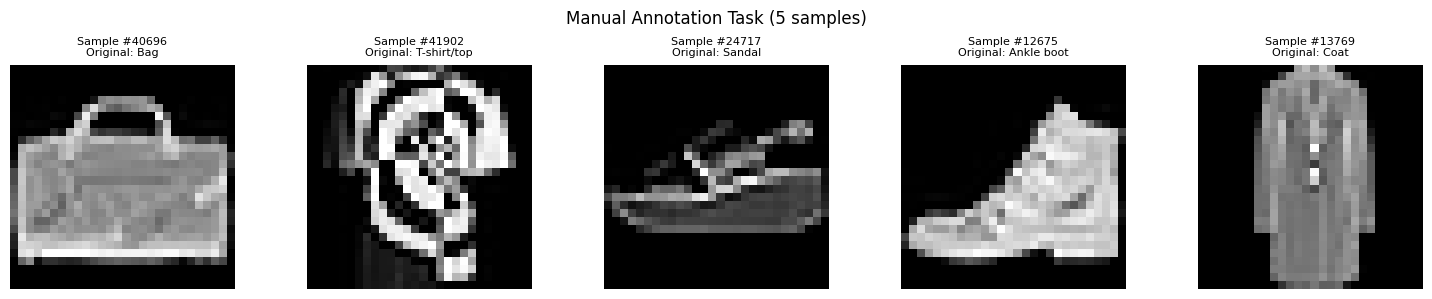

Sample #40696: Bag -- Note: Ambiguous -- double check
Sample #41902: T-shirt/top -- Note: Ambiguous -- double check
Sample #24717: Sandal -- Note: Clear
Sample #12675: Ankle boot -- Note: Clear
Sample #13769: Coat -- Note: Clear


In [7]:
def simulate_annotation_task(dataset, num_samples=5):
    indices = random.sample(range(len(dataset)), num_samples)
    annotations = {}

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i, idx in enumerate(indices):
        img, original_label = dataset[idx]
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"Sample #{idx}\nOriginal: {class_names[original_label]}", fontsize=8)
        axes[i].axis("off")

        annotations[idx] = {
            "original_label": class_names[original_label],
            "annotator_note": "Clear" if random.random() > 0.3 else "Ambiguous -- double check"
        }

    plt.suptitle("Manual Annotation Task (5 samples)")
    plt.tight_layout()
    plt.show()

    return annotations


annotation_results = simulate_annotation_task(train_raw, num_samples=5)
for idx, info in annotation_results.items():
    print(f"Sample #{idx}: {info['original_label']} -- Note: {info['annotator_note']}")

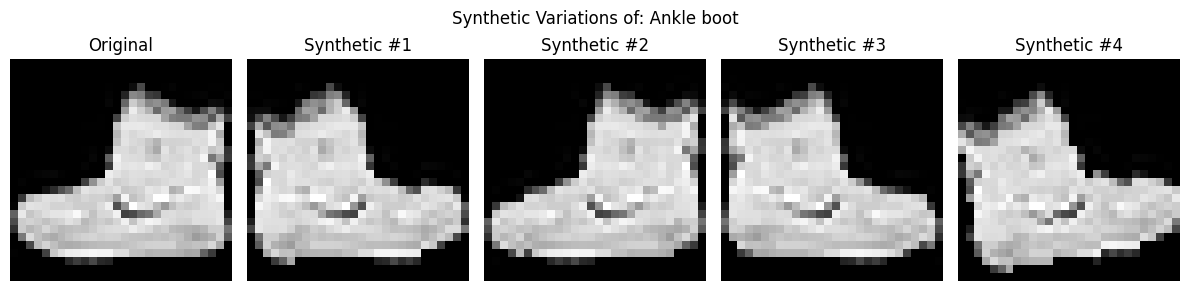

In [8]:
import torchvision.transforms as T

augmentation = T.Compose([
    T.RandomRotation(15),
    T.RandomHorizontalFlip(p=0.3),
])

original_img, original_label = train_raw[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(original_img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 5):
    augmented = augmentation(original_img)
    axes[i].imshow(augmented, cmap="gray")
    axes[i].set_title(f"Synthetic #{i}")
    axes[i].axis("off")

plt.suptitle(f"Synthetic Variations of: {class_names[original_label]}")
plt.tight_layout()
plt.show()